# Load DIV30 and DIV90 Raw 10x Samples to AnnData

This notebook defines a small in-notebook builder class for raw 10x sample loading. The immediate focus is DIV30, but the same object works for DIV90 or both time points by changing `target_divs`.

The builder reads per-sample 10x matrices from `metadata/div30_div90_sample_id_to_biolabel_map.tsv`, adds sample metadata to `.obs`, makes cell IDs unique by prefixing the 10x barcode with `run_sample_id`, and can return either a per-sample AnnData list or a combined AnnData object.


In [1]:
import os
from dataclasses import dataclass
from pathlib import Path
from typing import Optional, Sequence

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from scipy.stats import median_abs_deviation as mad

In [ ]:
@dataclass
class Raw10xAnnDataBuilder:
    """Minimal teaching builder: only methods used in this tutorial."""

    project_root: Path
    target_divs: Sequence[str] = ("DIV30",)
    target_run_sample_ids: Optional[Sequence[str]] = None
    sample_map_name: str = "metadata/div30_div90_sample_id_to_biolabel_map.tsv"
    strict_missing_matrix_dirs: bool = True

    @property
    def sample_map_tsv(self) -> Path:
        """Compute sample map path only (no file read)."""
        return self.project_root / self.sample_map_name

    def sample_table(self) -> pd.DataFrame:
        """Read/filter sample metadata, map run_sample_id -> cell_line, and derive matrix paths."""
        sample_metadata_df = pd.read_csv(self.sample_map_tsv, sep="\t")
        required = {"DIV", "run_sample_id", "biological_label", "per_sample_metrics_csv"}
        missing = required.difference(sample_metadata_df.columns)
        if missing:
            raise ValueError(f"Sample map is missing required columns: {sorted(missing)}")

        sample_metadata_df = sample_metadata_df[sample_metadata_df["DIV"].isin(self.target_divs)].copy()

        if self.target_run_sample_ids is not None:
            sample_metadata_df = sample_metadata_df[
                sample_metadata_df["run_sample_id"].isin(self.target_run_sample_ids)
            ].copy()
            found = set(sample_metadata_df["run_sample_id"].astype(str))
            missing_ids = [sid for sid in self.target_run_sample_ids if sid not in found]
            if missing_ids:
                raise ValueError(f"Missing requested run_sample_id values in sample map: {missing_ids}")

        if sample_metadata_df.empty:
            raise ValueError("No samples matched target_divs/target_run_sample_ids.")

        # Normalize replicate-level labels (e.g., H9_rep1) to canonical cell lines (H9/79B/2E).
        sample_metadata_df["cell_line"] = sample_metadata_df["biological_label"].astype("string").str.extract(
            r"^(H9|79B|2E)",
            expand=False,
        )

        invalid_rows = sample_metadata_df[sample_metadata_df["cell_line"].isna()][["run_sample_id", "biological_label"]]
        if not invalid_rows.empty:
            examples = invalid_rows.head(10).to_dict(orient="records")
            raise ValueError(
                "Could not map some biological_label values to expected cell_line prefixes "
                "(H9, 79B, 2E). Examples: "
                f"{examples}"
            )

        sample_metadata_df["DIV"] = pd.Categorical(sample_metadata_df["DIV"], categories=self.target_divs, ordered=True)
        if self.target_run_sample_ids is not None:
            sample_metadata_df["run_sample_id"] = pd.Categorical(
                sample_metadata_df["run_sample_id"],
                categories=self.target_run_sample_ids,
                ordered=True,
            )

        sample_metadata_df = sample_metadata_df.sort_values(["DIV", "run_sample_id"]).reset_index(drop=True)
        sample_metadata_df["matrix_dir"] = sample_metadata_df["per_sample_metrics_csv"].map(
            lambda p: str(Path(p).parent / "count" / "raw_feature_bc_matrix")
        )

        return sample_metadata_df[["DIV", "run_sample_id", "cell_line", "matrix_dir"]]

    def _load_component_adatas(self):
        """Load per-sample AnnData objects and return a dict keyed by run_sample_id."""
        sample_metadata_df = self.sample_table()
        sample_adatas_by_run = {}
        missing_dirs = []

        for _, row in sample_metadata_df.iterrows():
            matrix_dir = Path(row["matrix_dir"])
            if not matrix_dir.exists():
                missing_dirs.append(str(matrix_dir))
                continue

            one_sample_adata = sc.read_10x_mtx(matrix_dir, var_names="gene_symbols", make_unique=True)
            run_sample_id = str(row["run_sample_id"])

            one_sample_adata.obs_names = [f"{run_sample_id}:{barcode}" for barcode in one_sample_adata.obs_names]
            one_sample_adata.obs["DIV"] = str(row["DIV"])
            one_sample_adata.obs["run_sample_id"] = run_sample_id
            one_sample_adata.obs["cell_line"] = str(row["cell_line"])
            one_sample_adata.obs["matrix_dir"] = str(matrix_dir)
            sample_adatas_by_run[run_sample_id] = one_sample_adata

        if missing_dirs:
            message = "Missing per-sample 10x matrix directories:\n" + "\n".join(f" - {p}" for p in missing_dirs)
            if self.strict_missing_matrix_dirs:
                raise FileNotFoundError(message)
            print(message)

        if not sample_adatas_by_run:
            raise FileNotFoundError("No per-sample 10x matrix directories were found.")

        return sample_metadata_df, sample_adatas_by_run

    def per_sample_anndata_list(self):
        """Return per-sample AnnData objects as an ordered list plus matching run_sample_id names."""
        sample_metadata_df, sample_adatas_by_run = self._load_component_adatas()
        adata_names = sample_metadata_df["run_sample_id"].astype(str).tolist()
        adata_list = [sample_adatas_by_run[run_sample_id] for run_sample_id in adata_names]
        return adata_names, adata_list

    def _finalize_combined(self, combined_adata: ad.AnnData, sample_metadata_df: pd.DataFrame) -> ad.AnnData:
        """Apply common post-concatenation typing, checks, and provenance fields."""
        if not combined_adata.obs_names.is_unique:
            duplicated = combined_adata.obs_names[combined_adata.obs_names.duplicated()].unique()[:10].tolist()
            raise ValueError(f"Combined AnnData has duplicated obs_names. Examples: {duplicated}")

        combined_adata.obs["DIV"] = pd.Categorical(combined_adata.obs["DIV"], categories=self.target_divs, ordered=True)
        combined_adata.obs["run_sample_id"] = pd.Categorical(
            combined_adata.obs["run_sample_id"],
            categories=sample_metadata_df["run_sample_id"].astype(str).tolist(),
            ordered=True,
        )
        combined_adata.obs["cell_line"] = combined_adata.obs["cell_line"].astype("string")
        combined_adata.obs["matrix_dir"] = combined_adata.obs["matrix_dir"].astype("string")

        combined_adata.uns["sample_map_tsv"] = str(self.sample_map_tsv)
        combined_adata.uns["target_divs"] = list(self.target_divs)
        combined_adata.uns["combine_logic"] = (
            "Per-sample 10x matrices were read separately, annotated, barcode-prefixed by "
            "run_sample_id, and concatenated along observations with an outer gene join."
        )
        return combined_adata

    def combined_anndata_concat(self, join: str = "outer", label: str = "batch") -> ad.AnnData:
        """Alternative combine path using anndata.concat with a batch key in .obs."""
        sample_metadata_df, sample_adatas_by_run = self._load_component_adatas()
        combined_adata = ad.concat(
            sample_adatas_by_run,
            axis=0,
            join=join,
            merge="same",
            fill_value=0,
            index_unique=None,
            label=label,
        )

        # Ensure batch values are run_sample_id values, and keep run_sample_id explicit.
        if label in combined_adata.obs.columns:
            combined_adata.obs[label] = combined_adata.obs[label].astype("string")
            combined_adata.obs["run_sample_id"] = combined_adata.obs[label].astype("string")

        return self._finalize_combined(combined_adata, sample_metadata_df)

## Builder Instantiation Tutorial (Minimal Method Version)

This notebook now uses a simplified class that keeps only the methods needed for your learning path:

1. `sample_map_tsv` (property)
2. `sample_table()`
3. `per_sample_anndata_list()`
4. `combined_anndata_concat()`

Methods like `read_one_sample`, `component_anndatas`, `cell_count_tables`, and `anndata_set` were intentionally removed for clarity. Their logic is now either unnecessary for this tutorial or inlined.

### Seurat vs Scanpy data storage model

Here comes another difference from Seurat. The R package stores raw data, scaled data and variable genes information in separate slots, Scanpy instead keeps only one snapshot of the data.

In practice with AnnData, this means:

- active matrix is typically in `.X`
- optional alternatives can be stored in `.layers[...]`
- raw snapshot can be stored in `.raw`

### Naming clarification for cell identity and runtime variables

In this notebook, we now use `cell_line` as the explicit column name.

- Source metadata column: `biological_label`
- Tutorial/output column: `cell_line`
- Mapping rule: each `run_sample_id` maps directly to one canonical `cell_line` value.

Variable naming is now explicit:

- `anndata_builder`: configuration/helper object (not the expression matrix)
- `sample_metadata_df`: sample-level metadata table
- `combined_adata`: combined AnnData object in memory

### Where per-sample AnnData files are saved

Standalone raw save utility default location:

`$PROJECT_ROOT/raw_adata`

You should export `PROJECT_ROOT` first, for example:

`export PROJECT_ROOT=/nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_projectfolder`

Safety behavior:

- default mode is `dry_run=True` (no files written)
- default real-run mode uses `overwrite=False`
- existing files are never deleted
- existing files are not overwritten unless you explicitly set `overwrite=True`

### Two AnnData loading options

1. `anndata_builder.per_sample_anndata_list()`
- Returns `adata_names` and `adata_list` without concatenating samples.
- Use this when you want to iterate over one AnnData object per sample.

2. `anndata_builder.combined_anndata_concat(join="outer", label="batch")`
- Uses `anndata.concat` on a dict keyed by `run_sample_id`.
- Adds a `batch` column in `.obs` where values are the `run_sample_id` keys.
- Also keeps explicit `run_sample_id` in `.obs`.
- Supports join behavior via `join` (`"outer"` or `"inner"`).

### Mental model

- `anndata_builder = ...` is configuration.
- `sample_table()` is metadata I/O and label harmonization.
- `per_sample_anndata_list()` is matrix I/O + one object per sample.
- `combined_anndata_concat()` is matrix I/O + full combined object construction.
- raw save utility writes per-sample AnnData files only after a dry-run review.

In [3]:
# Tutorial cell: instantiate Raw10xAnnDataBuilder with explicit, traceable intent.
#

# -----------------------------------------------------------------------------
# 1) Find project root (pure path discovery; no data loading yet)
# -----------------------------------------------------------------------------
def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "metadata" / "div30_div90_sample_id_to_biolabel_map.tsv").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing metadata/div30_div90_sample_id_to_biolabel_map.tsv")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())

#print the project root to confirm it was found correctly
print("Project root found at:", PROJECT_ROOT)

# -----------------------------------------------------------------------------
# 2) Instantiate the configuration/helper object (no matrix I/O yet)
# -----------------------------------------------------------------------------
anndata_builder = Raw10xAnnDataBuilder(
    project_root=PROJECT_ROOT,
    target_divs=("DIV30",),
    target_run_sample_ids=(
        "9853-MW-1",
        "9853-MW-2",
        "9853-MW-3",
        "9853-MW-4",
        "9853-MW-5",
        "9853-MW-6",
    ),
)

# -----------------------------------------------------------------------------
# 3) Introspect what was created right now
# -----------------------------------------------------------------------------
print("Type(anndata_builder):", type(anndata_builder))
print("Builder configuration currently stored:")
print("  project_root:", anndata_builder.project_root)
print("  target_divs:", anndata_builder.target_divs)
print("  target_run_sample_ids:", anndata_builder.target_run_sample_ids)
print("  sample_map_name (default):", anndata_builder.sample_map_name)
print("  strict_missing_matrix_dirs (default):", anndata_builder.strict_missing_matrix_dirs)
print("  sample_map_tsv path:", anndata_builder.sample_map_tsv)

# -----------------------------------------------------------------------------
# 4) First operation that DOES perform I/O: sample_table()
# -----------------------------------------------------------------------------
sample_metadata_df = anndata_builder.sample_table()
print(f"Selected {len(sample_metadata_df)} samples from: {anndata_builder.sample_map_tsv}")
display(sample_metadata_df[["DIV", "run_sample_id", "cell_line", "matrix_dir"]])

Project root found at: /home/elcrespo/Desktop/githubprojects/mge_organoid_pipeline
Type(anndata_builder): <class '__main__.Raw10xAnnDataBuilder'>
Builder configuration currently stored:
  project_root: /home/elcrespo/Desktop/githubprojects/mge_organoid_pipeline
  target_divs: ('DIV30',)
  target_run_sample_ids: ('9853-MW-1', '9853-MW-2', '9853-MW-3', '9853-MW-4', '9853-MW-5', '9853-MW-6')
  sample_map_name (default): metadata/div30_div90_sample_id_to_biolabel_map.tsv
  strict_missing_matrix_dirs (default): True
  sample_map_tsv path: /home/elcrespo/Desktop/githubprojects/mge_organoid_pipeline/metadata/div30_div90_sample_id_to_biolabel_map.tsv
Selected 6 samples from: /home/elcrespo/Desktop/githubprojects/mge_organoid_pipeline/metadata/div30_div90_sample_id_to_biolabel_map.tsv


,DIV,run_sample_id,cell_line,matrix_dir
0,DIV30,9853-MW-1,H9,/nfs/turbo/umms-parent/Manny_test/9583-MW-rean...
1,DIV30,9853-MW-2,H9,/nfs/turbo/umms-parent/Manny_test/9583-MW-rean...
2,DIV30,9853-MW-3,79B,/nfs/turbo/umms-parent/Manny_test/9583-MW-rean...
3,DIV30,9853-MW-4,79B,/nfs/turbo/umms-parent/Manny_test/9583-MW-rean...
4,DIV30,9853-MW-5,2E,/nfs/turbo/umms-parent/Manny_test/9583-MW-rean...
5,DIV30,9853-MW-6,2E,/nfs/turbo/umms-parent/Manny_test/9583-MW-rean...


In [ ]:
# Standalone utility: save one raw AnnData file per sample to $PROJECT_ROOT/raw_adata.
# Filename prefix is derived from the Cell Ranger matrix path.
def save_raw_adatas_from_builder(
    anndata_builder: Raw10xAnnDataBuilder,
    output_dir: Path = None,
    compression: str = "gzip",
    dry_run: bool = True,
    overwrite: bool = False,
) -> pd.DataFrame:
    sample_metadata_df, sample_adatas_by_run = anndata_builder._load_component_adatas()

    # Default write location is driven by the exported PROJECT_ROOT environment variable.
    if output_dir is None:
        project_root_env = os.environ.get("PROJECT_ROOT")
        if not project_root_env:
            raise EnvironmentError(
                "PROJECT_ROOT is not set. Export it first, e.g. "
                "export PROJECT_ROOT=/nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_projectfolder"
            )
        output_dir = Path(project_root_env) / "raw_adata"

    output_dir = Path(output_dir)
    if not dry_run:
        output_dir.mkdir(parents=True, exist_ok=True)

    sample_meta_by_run = sample_metadata_df.copy()
    sample_meta_by_run["run_sample_id_str"] = sample_meta_by_run["run_sample_id"].astype(str)
    sample_meta_by_run = sample_meta_by_run.set_index("run_sample_id_str")

    write_records = []
    planned_paths = set()

    for run_sample_id, one_sample_adata in sample_adatas_by_run.items():
        matrix_dir = Path(sample_meta_by_run.loc[run_sample_id, "matrix_dir"])

        # Typical pattern: <prefix>/count/raw_feature_bc_matrix
        if "count" in matrix_dir.parts:
            count_idx = matrix_dir.parts.index("count")
            path_prefix = matrix_dir.parts[count_idx - 1] if count_idx > 0 else matrix_dir.parent.name
        else:
            path_prefix = matrix_dir.parent.name

        safe_prefix = str(path_prefix).replace(" ", "_")
        candidate_path = output_dir / f"{safe_prefix}.h5ad"

        # Never overwrite existing files unless explicitly requested.
        out_path = candidate_path
        if (not overwrite) and (out_path.exists() or str(out_path) in planned_paths):
            # Keep the matrix-path prefix but make filename unique for this sample.
            out_path = output_dir / f"{safe_prefix}__{run_sample_id}.h5ad"

        planned_paths.add(str(out_path))

        action = "dry_run"
        wrote_file = False

        if not dry_run:
            if out_path.exists() and not overwrite:
                action = "skipped_existing"
            else:
                # Use write_h5ad explicitly, as requested.
                one_sample_adata.write_h5ad(out_path, compression=compression)
                action = "written"
                wrote_file = True

        write_records.append(
            {
                "dry_run": bool(dry_run),
                "action": action,
                "wrote_file": wrote_file,
                "overwrite_enabled": bool(overwrite),
                "run_sample_id": run_sample_id,
                "cell_line": str(sample_meta_by_run.loc[run_sample_id, "cell_line"]),
                "matrix_dir": str(matrix_dir),
                "file_prefix": safe_prefix,
                "h5ad_path": str(out_path),
                "exists_after_run": out_path.exists(),
                "n_cells": int(one_sample_adata.n_obs),
                "n_genes": int(one_sample_adata.n_vars),
            }
        )

    return pd.DataFrame(write_records).sort_values(["file_prefix", "run_sample_id"]).reset_index(drop=True)

In [5]:
real_run_manifest_df = save_raw_adatas_from_builder(anndata_builder, dry_run=False, overwrite=False)
print("Written files:", (real_run_manifest_df["action"] == "written").sum())
print("Skipped existing files:", (real_run_manifest_df["action"] == "skipped_existing").sum())
print("Output directory:", Path(real_run_manifest_df["h5ad_path"].iloc[0]).parent)
display(real_run_manifest_df[["action", "run_sample_id", "cell_line", "file_prefix", "h5ad_path", "exists_after_run", "n_cells", "n_genes"]])

Written files: 0
Skipped existing files: 6
Output directory: /nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_projectfolder/raw_adata


,action,run_sample_id,cell_line,file_prefix,h5ad_path,exists_after_run,n_cells,n_genes
0,skipped_existing,9853-MW-1,H9,9853-MW-1,/nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_pr...,True,18047,18082
1,skipped_existing,9853-MW-2,H9,9853-MW-2,/nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_pr...,True,6060,18082
2,skipped_existing,9853-MW-3,79B,9853-MW-3,/nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_pr...,True,17928,18082
3,skipped_existing,9853-MW-4,79B,9853-MW-4,/nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_pr...,True,13047,18082
4,skipped_existing,9853-MW-5,2E,9853-MW-5,/nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_pr...,True,26408,18082
5,skipped_existing,9853-MW-6,2E,9853-MW-6,/nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_pr...,True,25530,18082


In [10]:
# Build an ordered list of per-sample AnnData objects without concatenating them.
adata_names, adata_list = anndata_builder.per_sample_anndata_list()

print("Number of AnnData objects:", len(adata_list))
print("Sample IDs:", adata_names)
print("All objects are AnnData:", all(isinstance(one_sample_adata, ad.AnnData) for one_sample_adata in adata_list))

for run_sample_id, one_sample_adata in zip(adata_names, adata_list):
    unique_run_ids = one_sample_adata.obs["run_sample_id"].nunique()
    print(
        run_sample_id,
        one_sample_adata.shape,
        "unique_cell_ids=",
        one_sample_adata.obs_names.is_unique,
        "obs_run_sample_id_count=",
        unique_run_ids,
    )

Number of AnnData objects: 6
Sample IDs: ['9853-MW-1', '9853-MW-2', '9853-MW-3', '9853-MW-4', '9853-MW-5', '9853-MW-6']
All objects are AnnData: True
9853-MW-1 (18047, 18082) unique_cell_ids= True obs_run_sample_id_count= 1
9853-MW-2 (6060, 18082) unique_cell_ids= True obs_run_sample_id_count= 1
9853-MW-3 (17928, 18082) unique_cell_ids= True obs_run_sample_id_count= 1
9853-MW-4 (13047, 18082) unique_cell_ids= True obs_run_sample_id_count= 1
9853-MW-5 (26408, 18082) unique_cell_ids= True obs_run_sample_id_count= 1
9853-MW-6 (25530, 18082) unique_cell_ids= True obs_run_sample_id_count= 1


## Per-Sample QC Annotation Only

This QC section does not filter or remove cells. It only annotates each per-sample AnnData object in `adata_list`.

There are two kinds of columns involved:

1. `calculate_qc_metrics()` uses Scanpy to add numeric QC metric columns to each sample's `.obs`, including `total_counts`, `log1p_total_counts`, and `pct_counts_mt`. It also adds `mt` to `.var` to mark mitochondrial genes.
2. `annotate_mad_qc()` adds this notebook's 0/1 QC annotation columns to each sample's `.obs`.

The annotation columns are stored per sample in `.obs`:

- `qc_mad_flag_log1p_total_counts`: `1` means the cell is outside the 5-MAD range for log total counts; `0` means it is not flagged by this rule.
- `qc_mad_flag_pct_counts_mt`: `1` means the cell is above the 3-MAD upper mitochondrial percentage cutoff; `0` means it is not flagged by this rule.

These are integer 0/1 flags so they are easy to count with `.sum()` and easy to convert to boolean masks with `.astype(bool)` later. Threshold details are stored in each sample's `.uns["qc_mad_annotation_rules"]`. The notebook prints a per-sample report showing starting cell count and how many cells are annotated for QC review. These counts are not removals.


QC annotation report: no cells are filtered or removed in this step.
0/1 QC flags live in each sample AnnData object's .obs table; 1 means flagged.
9853-MW-1: starting_n_cells=18047, annotated_for_review_n_cells=4049, annotated_for_review_pct=22.44%
9853-MW-2: starting_n_cells=6060, annotated_for_review_n_cells=1974, annotated_for_review_pct=32.57%
9853-MW-3: starting_n_cells=17928, annotated_for_review_n_cells=2025, annotated_for_review_pct=11.30%
9853-MW-4: starting_n_cells=13047, annotated_for_review_n_cells=3767, annotated_for_review_pct=28.87%
9853-MW-5: starting_n_cells=26408, annotated_for_review_n_cells=5818, annotated_for_review_pct=22.03%
9853-MW-6: starting_n_cells=25530, annotated_for_review_n_cells=5131, annotated_for_review_pct=20.10%


,run_sample_id,starting_n_cells,flagged_log1p_total_counts_n_cells,flagged_pct_counts_mt_n_cells,annotated_for_review_n_cells,annotated_for_review_pct
0,9853-MW-1,18047,880,3552,4049,22.435862
1,9853-MW-2,6060,524,1770,1974,32.574257
2,9853-MW-3,17928,724,1478,2025,11.295181
3,9853-MW-4,13047,1302,3371,3767,28.872538
4,9853-MW-5,26408,1484,5136,5818,22.031203
5,9853-MW-6,25530,1266,4582,5131,20.097924


0/1 QC columns stored in each AnnData .obs:
['qc_mad_outlier_log1p_total_counts', 'qc_mad_outlier_log1p_n_genes_by_counts', 'qc_mad_outlier_pct_counts_mt', 'qc_mad_outlier_any', 'qc_mad_pass', 'qc_mad_flag_log1p_total_counts', 'qc_mad_flag_pct_counts_mt']


,run_sample_id,metric,n_mads,upper_only,n_cells,median,mad,lower_bound,upper_bound
0,9853-MW-1,log1p_total_counts,5,False,18047,8.805975,0.349807,7.056941,10.555009
1,9853-MW-2,log1p_total_counts,5,False,6060,8.839566,0.399902,6.840055,10.839078
2,9853-MW-3,log1p_total_counts,5,False,17928,9.027739,0.399899,7.028246,11.027231
3,9853-MW-4,log1p_total_counts,5,False,13047,8.769352,0.268695,7.425878,10.112826
4,9853-MW-5,log1p_total_counts,5,False,26408,8.918115,0.309984,7.368194,10.468036
5,9853-MW-6,log1p_total_counts,5,False,25530,9.059808,0.301007,7.554771,10.564844


,run_sample_id,metric,n_mads,upper_only,n_cells,median,mad,lower_bound,upper_bound
0,9853-MW-1,pct_counts_mt,3,True,18047,0.271262,0.197962,-0.322623,0.865148
1,9853-MW-2,pct_counts_mt,3,True,6060,0.253131,0.153642,-0.207794,0.714056
2,9853-MW-3,pct_counts_mt,3,True,17928,0.337614,0.259633,-0.441283,1.116512
3,9853-MW-4,pct_counts_mt,3,True,13047,0.174825,0.103735,-0.136380,0.486031
4,9853-MW-5,pct_counts_mt,3,True,26408,0.201647,0.119875,-0.157979,0.561273
5,9853-MW-6,pct_counts_mt,3,True,25530,0.161742,0.086517,-0.097809,0.421293


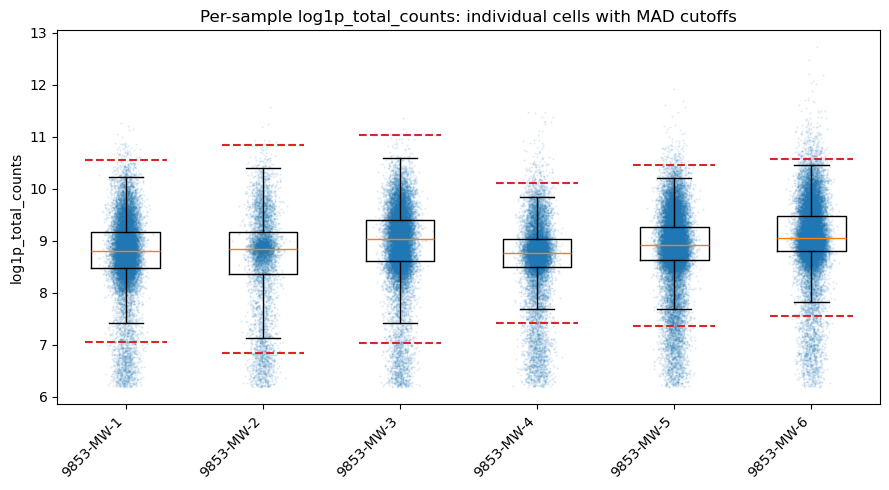

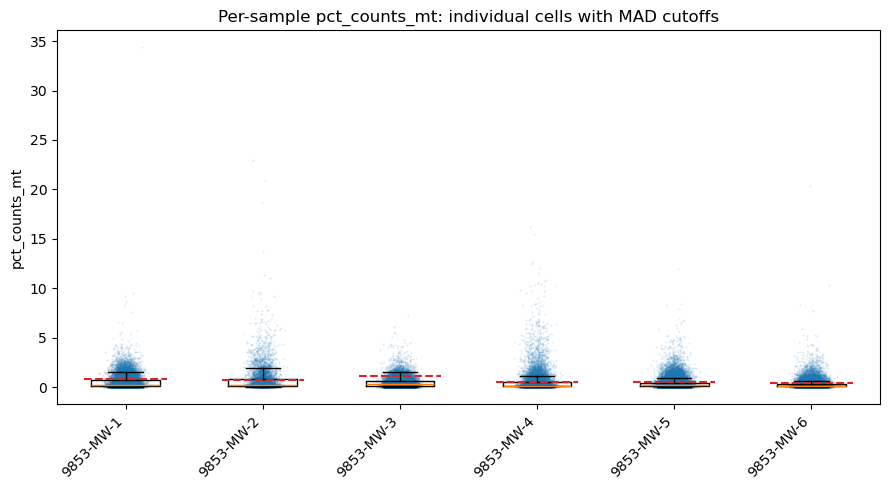

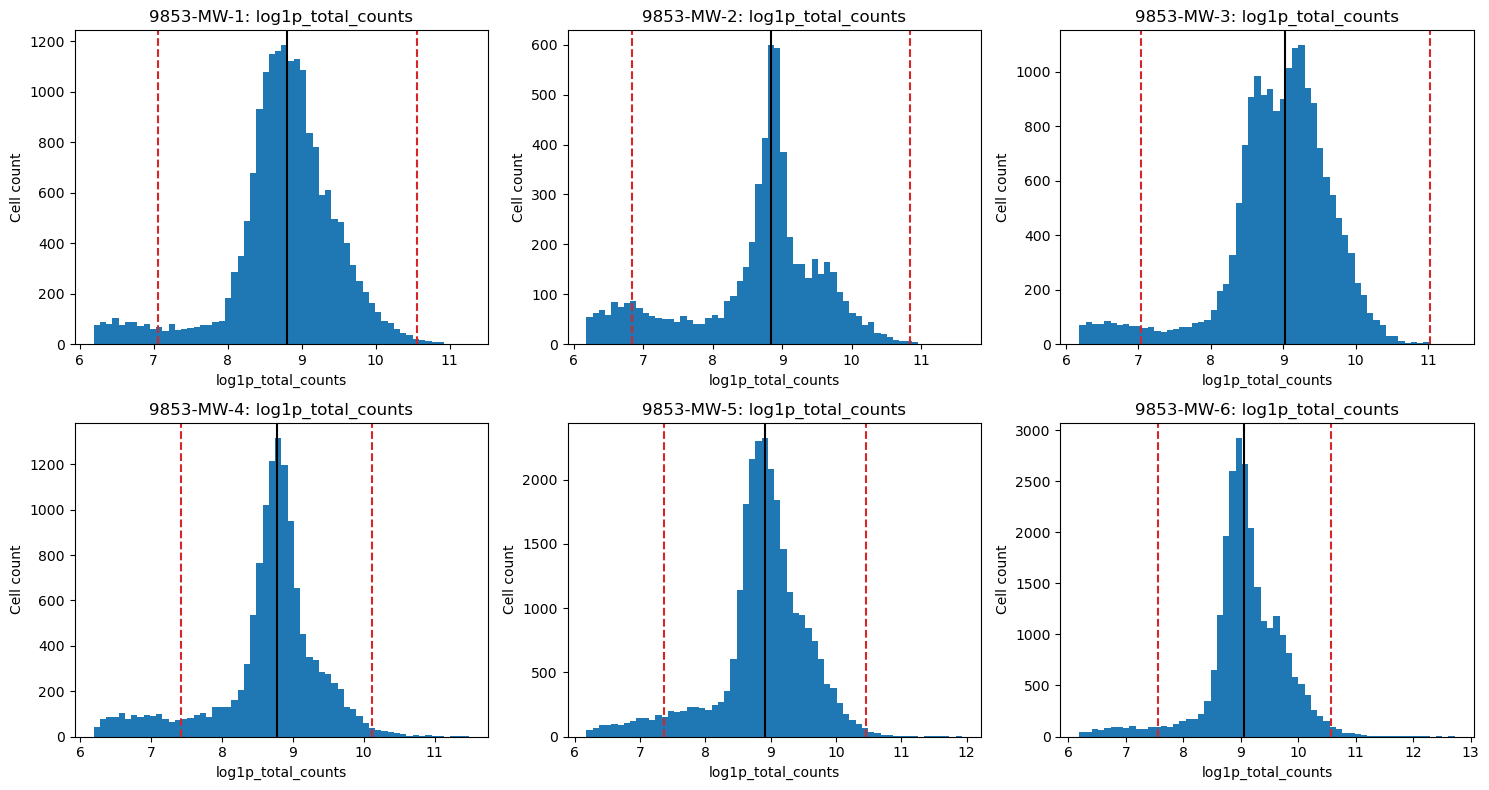

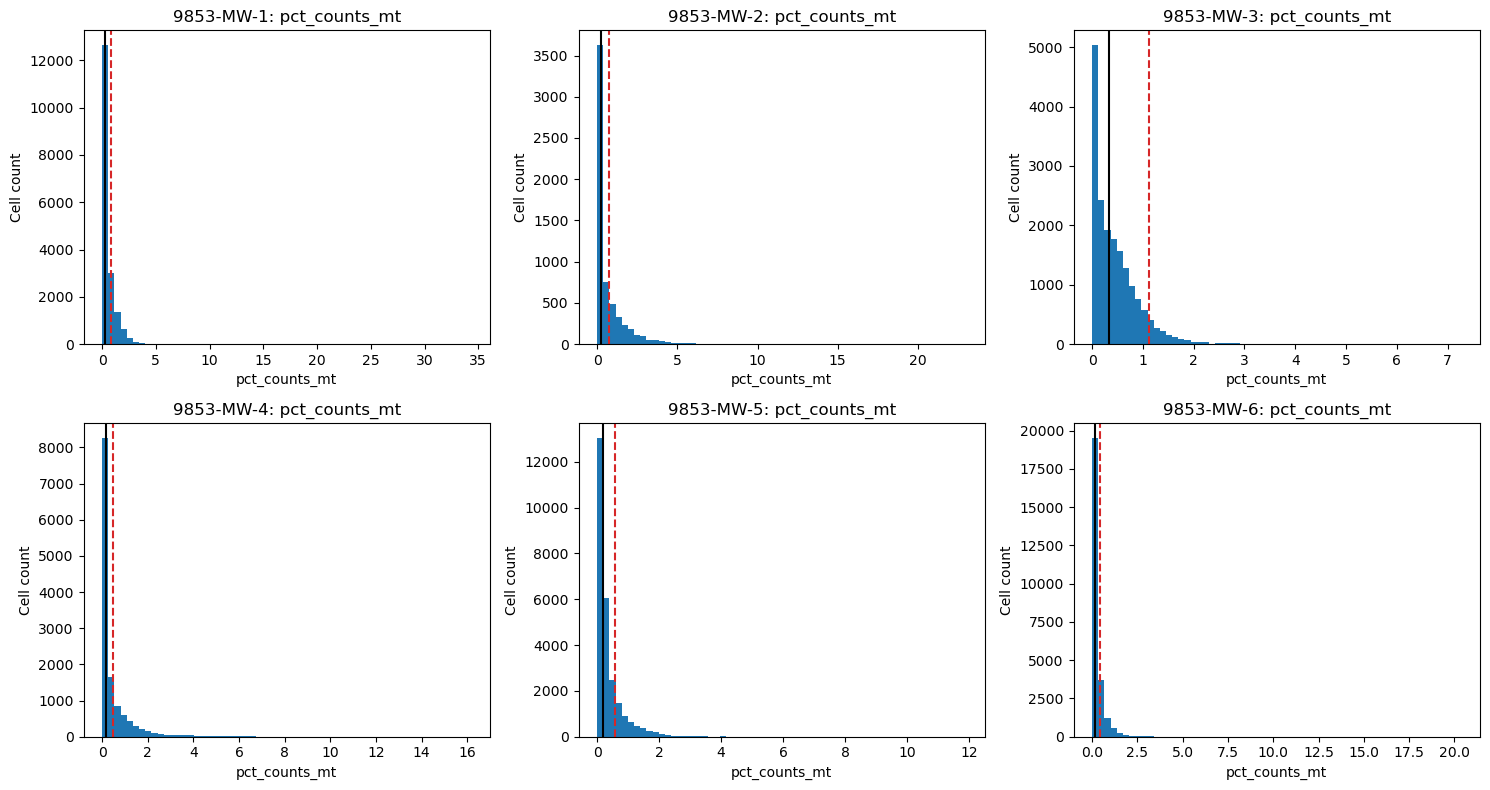

,run_sample_id,starting_n_cells,flagged_log1p_total_counts_n_cells,flagged_pct_counts_mt_n_cells,annotated_for_review_n_cells,annotated_for_review_pct
0,9853-MW-1,18047,880,3552,4049,22.435862
1,9853-MW-2,6060,524,1770,1974,32.574257
2,9853-MW-3,17928,724,1478,2025,11.295181
3,9853-MW-4,13047,1302,3371,3767,28.872538
4,9853-MW-5,26408,1484,5136,5818,22.031203
5,9853-MW-6,25530,1266,4582,5131,20.097924


In [20]:
@dataclass
class PerSampleMADQC:
    """Annotate and visualize per-sample QC flags for a list of AnnData objects.

    This class is intentionally annotation-only:
    - `calculate_qc_metrics()` adds numeric Scanpy QC metrics to `.obs`
    - `annotate_mad_qc()` adds this notebook's 0/1 QC flags to `.obs`
    - threshold metadata is stored in `.uns`
    - no cells are filtered, subsetted, removed, or changed in `.X`

    For the 0/1 flags created here, `1` means the cell is flagged by that
    criterion and `0` means it is not flagged by that criterion.
    """

    adata_names: Sequence[str]
    adata_list: Sequence[ad.AnnData]

    def calculate_qc_metrics(self, mito_prefix: str = "MT-", overwrite: bool = False):
        """Add Scanpy QC metric columns to each AnnData object's `.obs`.

        This step is separate from the 0/1 MAD annotations below.

        Scanpy adds numeric per-cell columns to `.obs`, including:
        - `total_counts`
        - `log1p_total_counts`
        - `pct_counts_mt`

        `mito_prefix="MT-"` is the human mitochondrial gene-name prefix,
        matching genes like `MT-ND1`, `MT-CO1`, and `MT-CYB`.

        `var["mt"]` is not a gene prefix. It is just the name of a boolean
        AnnData `.var` column created below. In that column, `True` means the
        gene name starts with the human mitochondrial prefix `MT-`.

        `qc_vars=["mt"]` tells Scanpy to use the `.var["mt"]` boolean column
        when calculating mitochondrial percentage columns such as
        `pct_counts_mt`.
        """
        required_obs_columns = {
            "total_counts",
            "log1p_total_counts",
            "pct_counts_mt",
        }

        for one_sample_adata in self.adata_list:
            missing_qc_columns = required_obs_columns.difference(one_sample_adata.obs.columns)
            if overwrite or missing_qc_columns:
                # Human mitochondrial genes usually start with "MT-".
                # Store that True/False gene annotation in .var["mt"].
                # Here, "mt" is only a column name, not the gene prefix.
                one_sample_adata.var["mt"] = one_sample_adata.var_names.str.startswith(mito_prefix)

                # Tell Scanpy to use .var["mt"] when computing mitochondrial QC metrics.
                # This creates .obs["pct_counts_mt"] among other numeric QC columns.
                sc.pp.calculate_qc_metrics(
                    one_sample_adata,
                    qc_vars=["mt"],
                    percent_top=None,
                    log1p=True,
                    inplace=True,
                )

        return list(self.adata_names), list(self.adata_list)

    def _sample_position(self, run_sample_id: str = None, sample_index: int = None) -> int:
        """Resolve either a run_sample_id or numeric list index to one position."""
        if run_sample_id is None and sample_index is None:
            raise ValueError("Provide run_sample_id or sample_index.")
        if run_sample_id is not None and sample_index is not None:
            raise ValueError("Provide only one of run_sample_id or sample_index.")

        if run_sample_id is not None:
            adata_names = list(self.adata_names)
            if run_sample_id not in adata_names:
                raise ValueError(f"Unknown run_sample_id: {run_sample_id}")
            return adata_names.index(run_sample_id)

        if sample_index < 0 or sample_index >= len(self.adata_list):
            raise IndexError(f"sample_index must be between 0 and {len(self.adata_list) - 1}.")
        return sample_index

    def metric_values(self, metric: str, run_sample_id: str = None, sample_index: int = None) -> np.ndarray:
        """Return finite values for one QC metric from one sample."""
        position = self._sample_position(run_sample_id=run_sample_id, sample_index=sample_index)
        one_sample_adata = self.adata_list[position]

        if metric not in one_sample_adata.obs.columns:
            raise KeyError(f"{metric!r} is not in .obs. Run calculate_qc_metrics() first.")

        values = one_sample_adata.obs[metric].to_numpy(dtype=float)
        return values[np.isfinite(values)]

    def mad_bounds(self, metric: str, run_sample_id: str = None, sample_index: int = None, n_mads: float = 5):
        """Return median +/- n_mads * MAD for one sample and one metric."""
        values = self.metric_values(metric=metric, run_sample_id=run_sample_id, sample_index=sample_index)
        median_value = float(np.median(values))
        mad_value = float(mad(values))
        lower_bound = median_value - n_mads * mad_value
        upper_bound = median_value + n_mads * mad_value

        return {
            "median": median_value,
            "mad": mad_value,
            "lower_bound": lower_bound,
            "upper_bound": upper_bound,
            "n_cells": int(values.size),
        }

    def mad_outlier_mask(self, one_sample_adata: ad.AnnData, metric: str, n_mads: float, upper_only: bool = False):
        """Return a boolean Series identifying MAD outliers for one metric."""
        if metric not in one_sample_adata.obs.columns:
            raise KeyError(f"{metric!r} is not in .obs. Run calculate_qc_metrics() first.")

        values = one_sample_adata.obs[metric].astype(float)
        median_value = float(np.median(values))
        mad_value = float(mad(values))
        lower_bound = median_value - n_mads * mad_value
        upper_bound = median_value + n_mads * mad_value

        if upper_only:
            return values > upper_bound
        return (values < lower_bound) | (values > upper_bound)

    def annotate_mad_qc(self):
        """Write 0/1 MAD QC annotations into each AnnData object's `.obs`.

        This method only annotates cells. It does not remove cells.

        Rules:
        - `log1p_total_counts`: 5 MADs, two-sided
        - `pct_counts_mt`: 3 MADs, upper-only

        Output columns added to `.obs`:
        - `qc_mad_flag_log1p_total_counts`
        - `qc_mad_flag_pct_counts_mt`

        In both columns, `1` means the cell is flagged by that criterion and
        `0` means it is not flagged by that criterion.
        """
        rules = [
            {
                "metric": "log1p_total_counts",
                "flag_column": "qc_mad_flag_log1p_total_counts",
                "n_mads": 5,
                "upper_only": False,
            },
            {
                "metric": "pct_counts_mt",
                "flag_column": "qc_mad_flag_pct_counts_mt",
                "n_mads": 3,
                "upper_only": True,
            },
        ]

        for run_sample_id, one_sample_adata in zip(self.adata_names, self.adata_list):
            threshold_records = []

            for rule in rules:
                metric = rule["metric"]
                flag_column = rule["flag_column"]
                n_mads = rule["n_mads"]
                upper_only = rule["upper_only"]

                mask = self.mad_outlier_mask(
                    one_sample_adata=one_sample_adata,
                    metric=metric,
                    n_mads=n_mads,
                    upper_only=upper_only,
                )
                one_sample_adata.obs[flag_column] = mask.astype("int8")

                bounds = self.mad_bounds(metric=metric, run_sample_id=run_sample_id, n_mads=n_mads)
                bounds.update(
                    {
                        "metric": metric,
                        "flag_column": flag_column,
                        "n_mads": n_mads,
                        "upper_only": upper_only,
                        "flag_meaning": "1 = flagged by this criterion; 0 = not flagged by this criterion",
                    }
                )
                threshold_records.append(bounds)

            one_sample_adata.uns["qc_mad_annotation_rules"] = threshold_records
            one_sample_adata.uns["qc_mad_annotation_note"] = (
                "Annotation only: 0/1 QC flags were added to .obs; no cells were filtered or removed."
            )

        return list(self.adata_names), list(self.adata_list)

    def annotate_manual_threshold(
        self,
        metric: str,
        threshold: float,
        direction: str = "above",
        column_name: str = None,
    ):
        """Annotate a user-defined threshold as a 0/1 `.obs` column.

        Use `direction='above'` for rules like pct_counts_mt > 25.
        Use `direction='below'` for rules like total_counts < 500.
        `1` means flagged by the manual rule; `0` means not flagged.
        """
        if direction not in {"above", "below"}:
            raise ValueError("direction must be 'above' or 'below'.")

        if column_name is None:
            operator_name = "gt" if direction == "above" else "lt"
            column_name = f"qc_manual_{metric}_{operator_name}_{threshold:g}"

        for one_sample_adata in self.adata_list:
            if metric not in one_sample_adata.obs.columns:
                raise KeyError(f"{metric!r} is not in .obs. Run calculate_qc_metrics() first.")

            values = one_sample_adata.obs[metric].astype(float)
            if direction == "above":
                mask = values > threshold
            else:
                mask = values < threshold
            one_sample_adata.obs[column_name] = mask.astype("int8")

            one_sample_adata.uns.setdefault("qc_manual_annotation_rules", []).append(
                {
                    "metric": metric,
                    "threshold": float(threshold),
                    "direction": direction,
                    "column_name": column_name,
                    "flag_meaning": "1 = flagged by this manual criterion; 0 = not flagged",
                    "note": "Annotation only: no cells were filtered or removed.",
                }
            )

        return list(self.adata_names), list(self.adata_list)

    def mad_bounds_table(self, metric: str = "log1p_total_counts", n_mads: float = 5, upper_only: bool = False) -> pd.DataFrame:
        """Return one MAD-threshold summary row per sample."""
        records = []

        for run_sample_id in self.adata_names:
            record = self.mad_bounds(metric=metric, run_sample_id=run_sample_id, n_mads=n_mads)
            record["run_sample_id"] = run_sample_id
            record["metric"] = metric
            record["n_mads"] = n_mads
            record["upper_only"] = upper_only
            records.append(record)

        return pd.DataFrame(records)[
            [
                "run_sample_id",
                "metric",
                "n_mads",
                "upper_only",
                "n_cells",
                "median",
                "mad",
                "lower_bound",
                "upper_bound",
            ]
        ]

    def qc_annotation_summary_table(self) -> pd.DataFrame:
        """Summarize 0/1 QC annotations per sample without filtering cells."""
        records = []

        for run_sample_id, one_sample_adata in zip(self.adata_names, self.adata_list):
            starting_n_cells = int(one_sample_adata.n_obs)
            total_count_flags = int(one_sample_adata.obs["qc_mad_flag_log1p_total_counts"].sum())
            mito_flags = int(one_sample_adata.obs["qc_mad_flag_pct_counts_mt"].sum())

            combined_review_mask = (
                one_sample_adata.obs["qc_mad_flag_log1p_total_counts"].astype(bool)
                | one_sample_adata.obs["qc_mad_flag_pct_counts_mt"].astype(bool)
            )
            annotated_for_review = int(combined_review_mask.sum())

            records.append(
                {
                    "run_sample_id": run_sample_id,
                    "starting_n_cells": starting_n_cells,
                    "flagged_log1p_total_counts_n_cells": total_count_flags,
                    "flagged_pct_counts_mt_n_cells": mito_flags,
                    "annotated_for_review_n_cells": annotated_for_review,
                    "annotated_for_review_pct": 100 * annotated_for_review / starting_n_cells,
                }
            )

        return pd.DataFrame(records)

    def print_annotation_report(self):
        """Print per-sample starting counts and 0/1 annotation counts."""
        summary_df = self.qc_annotation_summary_table()
        print("QC annotation report: no cells are filtered or removed in this step.")
        print("0/1 QC flags live in each sample AnnData object's .obs table; 1 means flagged.")

        for _, row in summary_df.iterrows():
            print(
                f"{row['run_sample_id']}: "
                f"starting_n_cells={int(row['starting_n_cells'])}, "
                f"annotated_for_review_n_cells={int(row['annotated_for_review_n_cells'])}, "
                f"annotated_for_review_pct={row['annotated_for_review_pct']:.2f}%"
            )

        return summary_df

    def plot_sample_distribution(
        self,
        metric: str = "log1p_total_counts",
        run_sample_id: str = None,
        sample_index: int = None,
        n_mads: float = 5,
        upper_only: bool = False,
        bins: int = 60,
        ax=None,
    ):
        """Plot one sample's metric distribution with MAD cutoff lines."""
        position = self._sample_position(run_sample_id=run_sample_id, sample_index=sample_index)
        resolved_run_sample_id = list(self.adata_names)[position]
        values = self.metric_values(metric=metric, sample_index=position)
        bounds = self.mad_bounds(metric=metric, sample_index=position, n_mads=n_mads)

        if ax is None:
            _, ax = plt.subplots(figsize=(6, 4))

        ax.hist(values, bins=bins)
        if not upper_only:
            ax.axvline(bounds["lower_bound"], color="tab:red", linestyle="--")
        ax.axvline(bounds["upper_bound"], color="tab:red", linestyle="--")
        ax.axvline(bounds["median"], color="black")
        ax.set_title(f"{resolved_run_sample_id}: {metric}")
        ax.set_xlabel(metric)
        ax.set_ylabel("Cell count")
        return ax

    def plot_all_distributions(
        self,
        metric: str = "log1p_total_counts",
        n_mads: float = 5,
        upper_only: bool = False,
        bins: int = 60,
    ):
        """Plot one MAD-threshold histogram panel per sample."""
        n_samples = len(self.adata_list)
        n_cols = min(3, n_samples)
        n_rows = int(np.ceil(n_samples / n_cols))
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), squeeze=False)

        for sample_index, ax in enumerate(axes.flat):
            if sample_index < n_samples:
                self.plot_sample_distribution(
                    metric=metric,
                    sample_index=sample_index,
                    n_mads=n_mads,
                    upper_only=upper_only,
                    bins=bins,
                    ax=ax,
                )
            else:
                ax.axis("off")

        fig.tight_layout()
        return fig

    def plot_metric_boxplot(self, metric: str, n_mads: float = 5, upper_only: bool = False):
        """Compare one QC metric across samples with boxes plus one dot per cell."""
        values_by_sample = [self.metric_values(metric=metric, sample_index=i) for i in range(len(self.adata_list))]
        positions = np.arange(1, len(values_by_sample) + 1)
        fig, ax = plt.subplots(figsize=(max(8, 1.5 * len(values_by_sample)), 5))
        ax.boxplot(values_by_sample, positions=positions, showfliers=False)

        rng = np.random.default_rng(0)
        for position, run_sample_id, values in zip(positions, self.adata_names, values_by_sample):
            jitter = rng.normal(loc=0, scale=0.05, size=len(values))
            ax.scatter(
                np.full(len(values), position) + jitter,
                values,
                s=2,
                alpha=0.15,
                linewidths=0,
                color="tab:blue",
            )

            bounds = self.mad_bounds(metric=metric, run_sample_id=run_sample_id, n_mads=n_mads)
            ax.hlines(bounds["upper_bound"], position - 0.3, position + 0.3, colors="tab:red", linestyles="--")
            if not upper_only:
                ax.hlines(bounds["lower_bound"], position - 0.3, position + 0.3, colors="tab:red", linestyles="--")

        ax.set_xticks(positions)
        ax.set_xticklabels(self.adata_names, rotation=45, ha="right")
        ax.set_ylabel(metric)
        ax.set_title(f"Per-sample {metric}: individual cells with MAD cutoffs")
        fig.tight_layout()
        return fig


qc_runner = PerSampleMADQC(adata_names=adata_names, adata_list=adata_list)

# Step 1: Scanpy-created numeric QC metrics.
# These are stored in each sample's .obs, while mitochondrial gene labels are stored in .var['mt'].
adata_names, adata_list = qc_runner.calculate_qc_metrics()

# Step 2: Notebook-created 0/1 QC annotations.
# These are stored in each sample's .obs. 1 means flagged; 0 means not flagged.
# This does not filter or remove cells.
adata_names, adata_list = qc_runner.annotate_mad_qc()

# Per-sample starting counts and annotation counts.
# `annotated_for_review_n_cells` is computed from the two 0/1 flag columns; it is not stored as another .obs column.
qc_annotation_summary_df = qc_runner.print_annotation_report()
display(qc_annotation_summary_df)

print("0/1 QC columns stored in each AnnData .obs:")
print([column for column in adata_list[0].obs.columns if column.startswith("qc_")])

qc_total_counts_mad_summary_df = qc_runner.mad_bounds_table(
    metric="log1p_total_counts",
    n_mads=5,
    upper_only=False,
)
display(qc_total_counts_mad_summary_df)

qc_mito_mad_summary_df = qc_runner.mad_bounds_table(
    metric="pct_counts_mt",
    n_mads=3,
    upper_only=True,
)
display(qc_mito_mad_summary_df)

# Overall per-sample distribution views.
qc_runner.plot_metric_boxplot(metric="log1p_total_counts", n_mads=5, upper_only=False)
plt.show()

qc_runner.plot_metric_boxplot(metric="pct_counts_mt", n_mads=3, upper_only=True)
plt.show()

# Detailed per-sample histograms, useful after the boxplots.
qc_runner.plot_all_distributions(metric="log1p_total_counts", n_mads=5, upper_only=False)
plt.show()

qc_runner.plot_all_distributions(metric="pct_counts_mt", n_mads=3, upper_only=True)
plt.show()

# Optional manual annotation example. Uncomment to add a fixed mitochondrial threshold flag.
# adata_names, adata_list = qc_runner.annotate_manual_threshold(
#     metric="pct_counts_mt",
#     threshold=25,
#     direction="above",
#     column_name="qc_manual_pct_counts_mt_gt_25",
# )


# total of cell after filer is 
qc_runner.qc_annotation_summary_table()


In [ ]:
# Build one combined AnnData object for downstream Scanpy work.
# This creates one matrix, not a list of AnnData objects.
# Adds .obs['batch'] using run_sample_id keys.
combined_adata = anndata_builder.combined_anndata_concat(join="outer", label="batch")

print("Combined AnnData shape:", combined_adata.shape)
print("Loaded run_sample_id count:", combined_adata.obs["run_sample_id"].nunique())
print("Unique cell IDs:", combined_adata.obs_names.is_unique)
print("Has batch column:", "batch" in combined_adata.obs.columns)

Combined AnnData shape: (107020, 18082)
Loaded run_sample_id count: 6
Unique cell IDs: True
Has batch column: True
